# Deep Q-Networks

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [40]:
# 1. Simple Neural Network to approximate Q-values
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

## Train loop for vanilla DQN

In [41]:

import gymnasium as gym
import highway_env
import json

def train_vanilla(episodes=3000):
    env = gym.make('highway-v0')
    state_dim = np.prod(env.observation_space.shape)
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = q_net.to(device)

    print(f"Training on: {device}")
    print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

    optimizer = optim.Adam(q_net.parameters(), lr=0.0001)
    loss_fn = nn.MSELoss()

    rewards_history = []
    loss_history = []

    # Hyperparameters
    gamma = 0.99
    epsilon = 1.0
    epsilon_decay = 0.995
    episodes = episodes

    for ep in range(episodes):
        state, _ = env.reset()
        done = False

        total_loss = 0
        total_reward = 0

        while not done:
            state_tensor = torch.FloatTensor(state.flatten()).to(device)

            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = q_net(state_tensor).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

            # Prepare Target
            next_state_tensor = torch.FloatTensor(next_state.flatten()).to(device)

            with torch.no_grad():
                next_q_values = q_net(next_state_tensor)
                max_next_q = torch.max(next_q_values)
                # Bellman Target: r + gamma * max(Q(s', a'))
                target_q = reward + (gamma * max_next_q * (1 - terminated))
                target_q = target_q.to(device)

            # Current Q-value prediction
            current_q = q_net(state_tensor)[action]

            # Backpropagation
            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            total_loss += loss.item()
            optimizer.step()

            state = next_state

        epsilon = max(0.01, epsilon * epsilon_decay)

        rewards_history.append(total_reward)
        loss_history.append(total_loss)

        print(f"Episode {ep+1} | Reward: {total_reward:.2f} | Loss: {total_loss:.4f} | Epsilon: {epsilon:.2f}")

    env.close()
    with open('vanilla_dqn_history.json', 'w') as f:
        json.dump({'rewards': rewards_history, 'losses': loss_history}, f)
    torch.save(q_net.state_dict(), 'checkpoints/vanilla_dqn.pth')
    return q_net, rewards_history, loss_history


In [42]:
train_vanilla()

Training on: cuda
GPU name: NVIDIA GeForce RTX 5060 Laptop GPU
Episode 1 | Reward: 2.77 | Loss: 3.5903 | Epsilon: 0.99
Episode 2 | Reward: 27.12 | Loss: 33.1599 | Epsilon: 0.99
Episode 3 | Reward: 17.59 | Loss: 22.8503 | Epsilon: 0.99
Episode 4 | Reward: 3.33 | Loss: 4.1227 | Epsilon: 0.98
Episode 5 | Reward: 1.25 | Loss: 1.2472 | Epsilon: 0.98
Episode 6 | Reward: 16.26 | Loss: 20.6042 | Epsilon: 0.97
Episode 7 | Reward: 10.44 | Loss: 12.7534 | Epsilon: 0.97
Episode 8 | Reward: 12.36 | Loss: 13.9311 | Epsilon: 0.96
Episode 9 | Reward: 6.32 | Loss: 7.3825 | Epsilon: 0.96
Episode 10 | Reward: 1.93 | Loss: 2.1771 | Epsilon: 0.95
Episode 11 | Reward: 6.42 | Loss: 7.9175 | Epsilon: 0.95
Episode 12 | Reward: 9.00 | Loss: 10.9847 | Epsilon: 0.94
Episode 13 | Reward: 6.24 | Loss: 7.3735 | Epsilon: 0.94
Episode 14 | Reward: 2.69 | Loss: 3.2002 | Epsilon: 0.93
Episode 15 | Reward: 8.81 | Loss: 10.1673 | Epsilon: 0.93
Episode 16 | Reward: 10.55 | Loss: 12.6488 | Epsilon: 0.92
Episode 17 | Reward:

(QNetwork(
   (fc): Sequential(
     (0): Linear(in_features=25, out_features=64, bias=True)
     (1): ReLU()
     (2): Linear(in_features=64, out_features=5, bias=True)
   )
 ),
 [np.float64(2.7726558084836497),
  np.float64(27.121412471428442),
  np.float64(17.593997131835863),
  np.float64(3.327644093745221),
  np.float64(1.2531265116271388),
  np.float64(16.255645298516818),
  np.float64(10.440476342350038),
  np.float64(12.357557876333416),
  np.float64(6.3248369222006335),
  np.float64(1.9336966941306792),
  np.float64(6.417544237992828),
  np.float64(9.001066818585828),
  np.float64(6.236601503716747),
  np.float64(2.686830785713442),
  np.float64(8.810390252334503),
  np.float64(10.547992436559557),
  np.float64(5.0620848213406076),
  np.float64(27.026694149553542),
  np.float64(11.062656462092269),
  np.float64(1.7096236574691714),
  np.float64(2.65039984497239),
  np.float64(6.771161486091001),
  np.float64(9.401900185005207),
  np.float64(5.247638044354034),
  np.float64(4.7

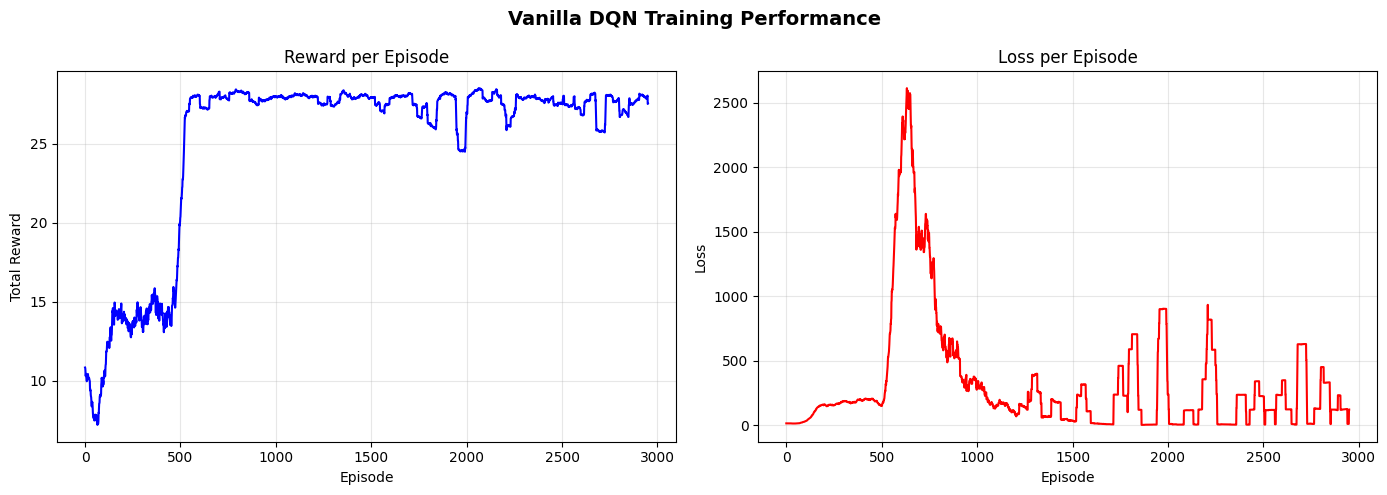

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('vanilla_dqn_history.json', 'r') as f:
    history = json.load(f)

rewards_history = history['rewards']
loss_history = history['losses']

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vanilla DQN Training Performance', fontsize=14, fontweight='bold')

axes[0].plot(smooth(rewards_history), color='blue')
axes[0].set_title('Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].grid(True, alpha=0.3)

axes[1].plot(smooth(loss_history), color='red')
axes[1].set_title('Loss per Episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
print("Average reward of last 100 episodes: ", np.mean(rewards_history[-100:]))
print("Maximum reward ", np.max(rewards_history))
print("Average reward of last 100 episodes: ", np.mean(loss_history[-100:]))

Average reward of last 100 episodes:  27.682774359569386
Maximum reward  33.683690744666585
Average reward of last 100 episodes:  175.22159171196807


## 1st Improvement: Target Q-Network

In [43]:

import gymnasium as gym
import highway_env
import json

def train_target_qnetwork(episodes=3000):
    env = gym.make('highway-v0')
    state_dim = np.prod(env.observation_space.shape)
    action_dim = env.action_space.n

    policy_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    policy_net = policy_net.to(device)
    target_net = target_net.to(device)

    print(f"Training on: {device}")
    print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

    optimizer = optim.Adam(policy_net.parameters(), lr=0.0001)
    loss_fn = nn.MSELoss()

    # Hyperparameters
    gamma = 0.99
    epsilon = 1.0
    epsilon_decay = 0.995
    episodes = episodes
    target_rewards_history = []
    target_loss_history = []
    target_update_freq = 10

    for ep in range(episodes):
        total_loss = 0
        total_reward = 0
        state, _ = env.reset()
        done = False
        step_count = 0

        while not done:
            step_count += 1
            state_tensor = torch.FloatTensor(state.flatten()).to(device)

            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = policy_net(state_tensor).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

            # Prepare Target
            next_state_tensor = torch.FloatTensor(next_state.flatten()).to(device)

            with torch.no_grad():
                next_q_values = target_net(next_state_tensor)
                max_next_q = torch.max(next_q_values)
                # Bellman Target: r + gamma * max(Q(s', a'))
                target_q = reward + (gamma * max_next_q * (1 - terminated))
                target_q = target_q.to(device)

            # Current Q-value prediction
            current_q = policy_net(state_tensor)[action]

            # Backpropagation
            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            total_loss += loss.item()
            optimizer.step()

            state = next_state

            avg_reward = total_reward / step_count
            avg_loss = total_loss / step_count


        if ep % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        epsilon = max(0.01, epsilon * epsilon_decay)
        target_rewards_history.append(total_reward)
        target_loss_history.append(total_loss)


        print(f"Episode {ep+1} | Average Reward: {avg_reward:.2f} | Average Loss: {avg_loss:.4f} | Epsilon: {epsilon:.2f}")

    env.close()
    torch.save(target_net.state_dict(), 'checkpoints/target_dqn.pth')
    with open('target_dqn_history.json', 'w') as f:
      json.dump({'rewards': target_rewards_history, 'losses': target_loss_history}, f)
    return policy_net, target_rewards_history, target_loss_history

policy_net, target_rewards_history, target_loss_history = train_target_qnetwork()


Training on: cuda
GPU name: NVIDIA GeForce RTX 5060 Laptop GPU
Episode 1 | Average Reward: 0.75 | Average Loss: 0.6930 | Epsilon: 0.99
Episode 2 | Average Reward: 0.75 | Average Loss: 0.6893 | Epsilon: 0.99
Episode 3 | Average Reward: 0.74 | Average Loss: 0.6326 | Epsilon: 0.99
Episode 4 | Average Reward: 0.88 | Average Loss: 0.9548 | Epsilon: 0.98
Episode 5 | Average Reward: 0.82 | Average Loss: 0.8043 | Epsilon: 0.98
Episode 6 | Average Reward: 0.69 | Average Loss: 0.5633 | Epsilon: 0.97
Episode 7 | Average Reward: 0.73 | Average Loss: 0.6119 | Epsilon: 0.97
Episode 8 | Average Reward: 0.78 | Average Loss: 0.6931 | Epsilon: 0.96
Episode 9 | Average Reward: 0.74 | Average Loss: 0.6417 | Epsilon: 0.96
Episode 10 | Average Reward: 0.75 | Average Loss: 0.6088 | Epsilon: 0.95
Episode 11 | Average Reward: 0.67 | Average Loss: 0.5367 | Epsilon: 0.95
Episode 12 | Average Reward: 0.79 | Average Loss: 0.7564 | Epsilon: 0.94
Episode 13 | Average Reward: 0.65 | Average Loss: 0.6031 | Epsilon: 0.

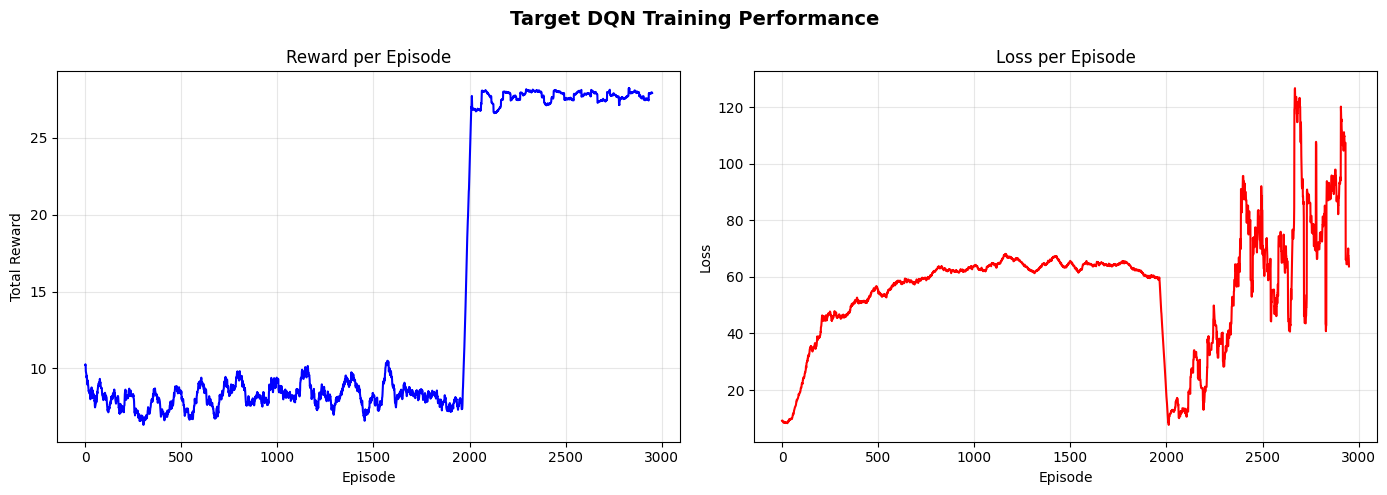

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('target_dqn_history.json', 'r') as f:
    history = json.load(f)

rewards_history = history['rewards']
loss_history = history['losses']

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target DQN Training Performance', fontsize=14, fontweight='bold')

axes[0].plot(smooth(rewards_history), color='blue')
axes[0].set_title('Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].grid(True, alpha=0.3)

axes[1].plot(smooth(loss_history), color='red')
axes[1].set_title('Loss per Episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print("Average reward of last 100 episodes: ", np.mean(rewards_history[-100:]))
print("Maximum reward ", np.max(rewards_history))
print("Average reward of last 100 episodes: ", np.mean(loss_history[-100:]))

Average reward of last 100 episodes:  27.762799622785163
Maximum reward  32.48362977638433
Average reward of last 100 episodes:  78.58908834183822


## 2nd Improvement: Double DQN

In [44]:
import gymnasium as gym
import highway_env

def train_double_dqn(episodes=3000):
    env = gym.make('highway-v0')
    state_dim = np.prod(env.observation_space.shape)
    action_dim = env.action_space.n

    policy_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    policy_net = policy_net.to(device)
    target_net = target_net.to(device)

    print(f"Training on: {device}")
    print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

    optimizer = optim.Adam(policy_net.parameters(), lr=0.0001)
    loss_fn = nn.MSELoss()

    gamma = 0.99
    epsilon = 1.0
    min_epsilon = 0.01
    target_update_freq = 10
    epsilon_decay = 0.995


    ddqn_rewards_history = []
    ddqn_loss_history = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False

        total_loss = 0
        total_reward = 0
        step_count = 0

        while not done:
            step_count += 1
            state_tensor = torch.tensor(state.flatten(), dtype=torch.float32, device=device)

            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = policy_net(state_tensor).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            next_state_tensor = torch.tensor(next_state.flatten(), dtype=torch.float32, device=device)

            with torch.no_grad():
                next_action = policy_net(next_state_tensor).argmax()
                next_q_value = target_net(next_state_tensor)[next_action]
                target_q = torch.tensor(reward, dtype=torch.float32, device=device) + gamma * next_q_value * (1 - int(done))

            current_q = policy_net(state_tensor)[action]

            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            state = next_state

        if ep % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        avg_loss = total_loss / max(step_count, 1)

        ddqn_rewards_history.append(total_reward)
        ddqn_loss_history.append(total_loss)

        print(
            f"Episode {ep + 1} | "
            f"Reward: {total_reward:.2f} | "
            f"Loss: {total_loss:.4f} | "
            f"Epsilon: {epsilon:.2f}"
        )

    env.close()
    torch.save(target_net.state_dict(), 'checkpoints/double_dqn.pth')
    with open('double_dqn_history.json', 'w') as f:
      json.dump({'rewards': ddqn_rewards_history, 'losses': ddqn_loss_history}, f)
    return policy_net, ddqn_rewards_history, ddqn_loss_history

double_dqn_model, double_dqn_rewards, double_dqn_losses = train_double_dqn()

Training on: cuda
GPU name: NVIDIA GeForce RTX 5060 Laptop GPU
Episode 1 | Reward: 5.72 | Loss: 10.0219 | Epsilon: 0.99
Episode 2 | Reward: 30.52 | Loss: 45.0189 | Epsilon: 0.99
Episode 3 | Reward: 15.73 | Loss: 21.9530 | Epsilon: 0.99
Episode 4 | Reward: 23.06 | Loss: 31.4446 | Epsilon: 0.98
Episode 5 | Reward: 1.86 | Loss: 2.3463 | Epsilon: 0.98
Episode 6 | Reward: 23.23 | Loss: 29.1964 | Epsilon: 0.97
Episode 7 | Reward: 30.68 | Loss: 34.6736 | Epsilon: 0.97
Episode 8 | Reward: 22.72 | Loss: 25.8129 | Epsilon: 0.96
Episode 9 | Reward: 2.05 | Loss: 2.7113 | Epsilon: 0.96
Episode 10 | Reward: 1.86 | Loss: 2.2666 | Epsilon: 0.95
Episode 11 | Reward: 8.50 | Loss: 9.2117 | Epsilon: 0.95
Episode 12 | Reward: 7.26 | Loss: 8.6115 | Epsilon: 0.94
Episode 13 | Reward: 20.35 | Loss: 27.0622 | Epsilon: 0.94
Episode 14 | Reward: 15.59 | Loss: 26.1004 | Epsilon: 0.93
Episode 15 | Reward: 21.30 | Loss: 28.5736 | Epsilon: 0.93
Episode 16 | Reward: 5.07 | Loss: 5.7387 | Epsilon: 0.92
Episode 17 | Re

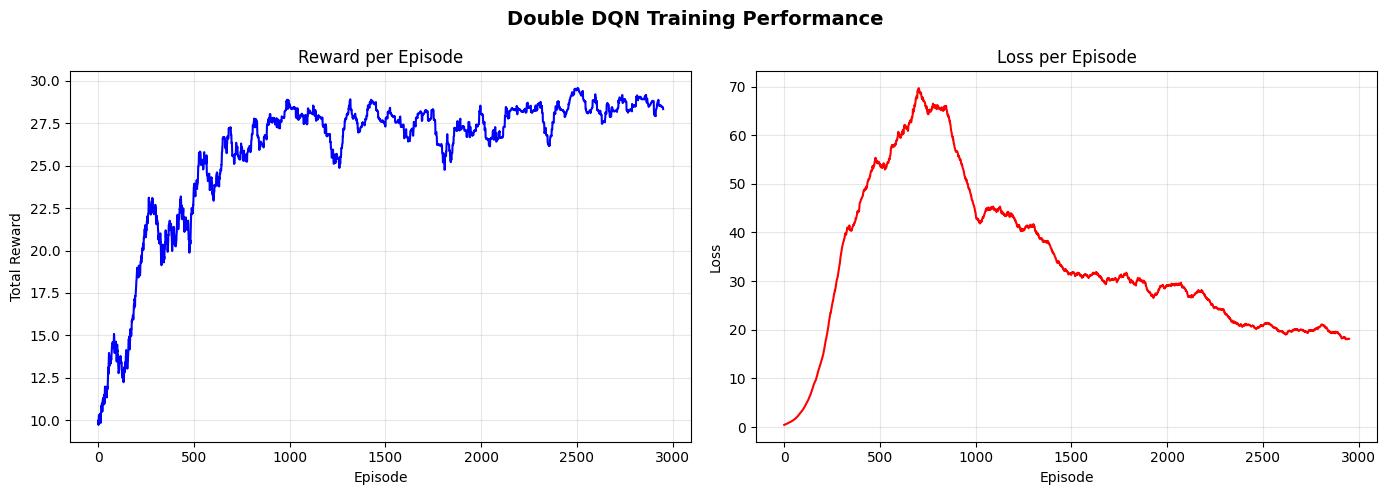

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('double_dqn_history.json', 'r') as f:
    history = json.load(f)

rewards_history = history['rewards']
loss_history = history['losses']

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Double DQN Training Performance', fontsize=14, fontweight='bold')

axes[0].plot(smooth(rewards_history), color='blue')
axes[0].set_title('Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].grid(True, alpha=0.3)

axes[1].plot(smooth(loss_history), color='red')
axes[1].set_title('Loss per Episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print("Average reward of last 100 episodes: ", np.mean(rewards_history[-100:]))
print("Maximum reward ", np.max(rewards_history))
print("Average reward of last 100 episodes: ", np.mean(loss_history[-100:]))

Average reward of last 100 episodes:  28.561305406600805
Maximum reward  34.35603699593619
Average reward of last 100 episodes:  18.59995732572098


### Print comparison plots

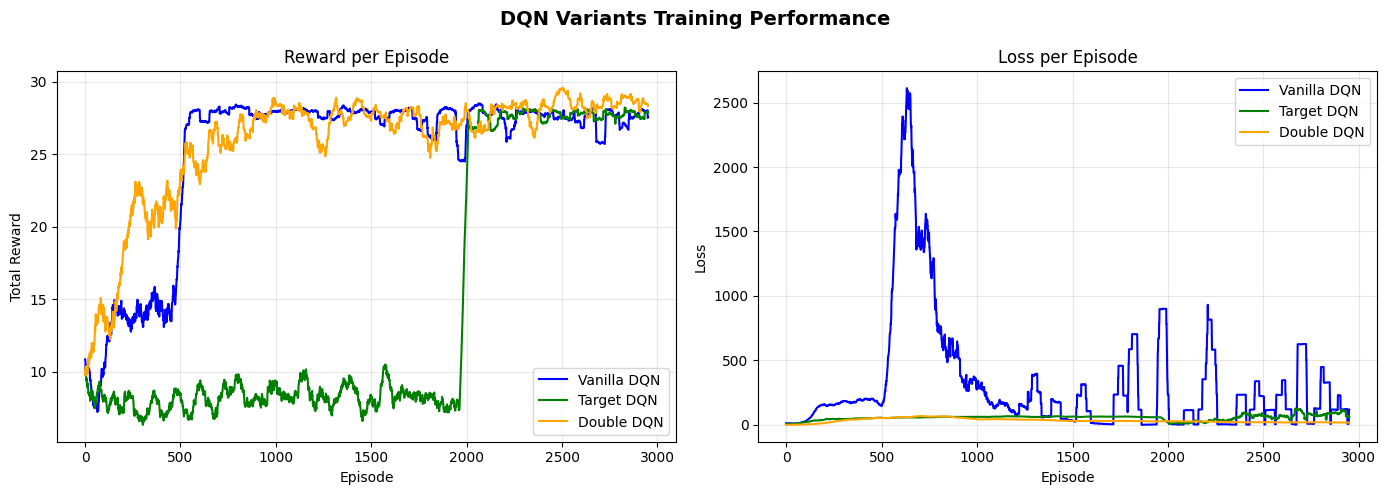

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load all histories
with open('vanilla_dqn_history.json', 'r') as f:
    vanilla = json.load(f)

with open('target_dqn_history.json', 'r') as f:
    target = json.load(f)

with open('double_dqn_history.json', 'r') as f:
    double = json.load(f)

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DQN Variants Training Performance', fontsize=14, fontweight='bold')

# Reward comparison
axes[0].plot(smooth(vanilla['rewards']), color='blue', label='Vanilla DQN')
axes[0].plot(smooth(target['rewards']), color='green', label='Target DQN')
axes[0].plot(smooth(double['rewards']), color='orange', label='Double DQN')
axes[0].set_title('Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(smooth(vanilla['losses']), color='blue', label='Vanilla DQN')
axes[1].plot(smooth(target['losses']), color='green', label='Target DQN')
axes[1].plot(smooth(double['losses']), color='orange', label='Double DQN')
axes[1].set_title('Loss per Episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_comparison.png', dpi=150)
plt.show()